# CIFAR‑10 CNN in PyTorch — documented & tutorial-style

Mirrors the TF tutorial and adds the same visualizations: 5×5 image grid, training curves, single‑image prediction + bar chart, and a grid of predictions with bars.


## Model architecture & shapes

```
Input : (N, 3, 32, 32)
Conv2d(3→32, 3×3, pad=1) → ReLU            → (N, 32, 32, 32)
MaxPool2d(2×2)                             → (N, 32, 16, 16)

Conv2d(32→64, 3×3, pad=1) → ReLU           → (N, 64, 16, 16)
MaxPool2d(2×2)                             → (N, 64, 8, 8)

Conv2d(64→64, 3×3, pad=1) → ReLU           → (N, 64, 8, 8)

Flatten                                      (N, 64·8·8 = 4096)
Linear(4096→64) → ReLU
Linear(64→10)  → logits
```


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:

SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device :', device)


PyTorch: 2.6.0
Device : cpu


In [3]:

transform = transforms.Compose([transforms.ToTensor()])
full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_ds    = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

val_size = 10000
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Train/Val/Test sizes: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}')


Train/Val/Test sizes: 40000/10000/10000


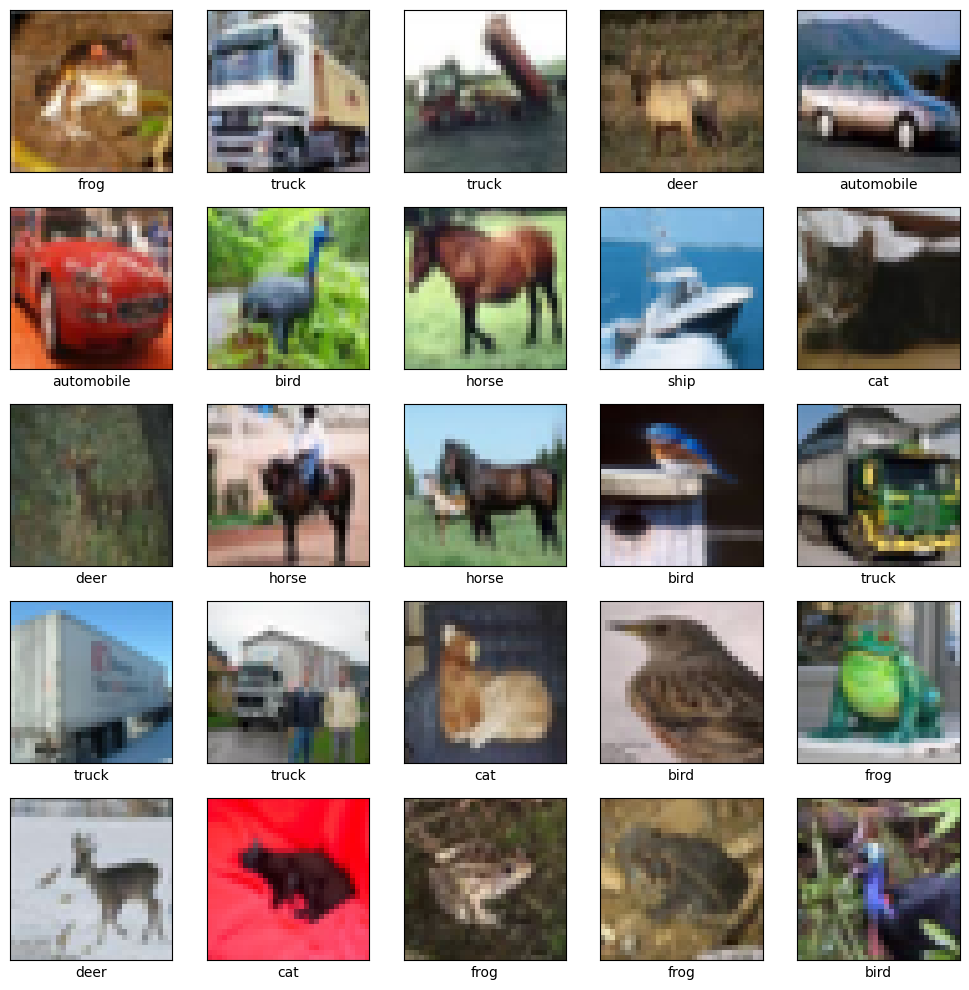

In [4]:

fig = plt.figure(figsize=(6,6))
for i in range(25):
    img, label = full_train[i]
    npimg = img.permute(1,2,0).numpy()
    ax = plt.subplot(5,5,i+1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(npimg)
    ax.set_xlabel(class_names[label])
plt.tight_layout(); plt.show()


In [5]:

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 64), nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)
print(model)
print('Total parameters:', sum(p.numel() for p in model.parameters()))


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)
Total parameters: 319178


In [6]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    total, correct, running_loss = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train:
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * xb.size(0)
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return running_loss/total, correct/total

EPOCHS = 15
history = {'acc': [], 'val_acc': [], 'loss': [], 'val_loss': []}
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    history['loss'].append(tr_loss); history['acc'].append(tr_acc)
    history['val_loss'].append(va_loss); history['val_acc'].append(va_acc)
    print(f'Epoch {epoch:2d}/{EPOCHS} - loss: {tr_loss:.4f} - acc: {tr_acc:.4f} - val_loss: {va_loss:.4f} - val_acc: {va_acc:.4f}')


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


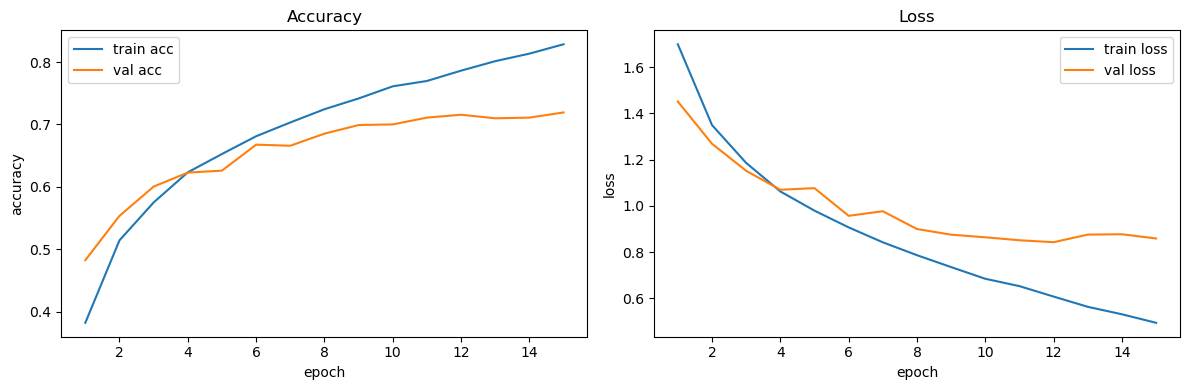

In [7]:

epochs = np.arange(1, len(history['acc'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history['acc'], label='train acc')
plt.plot(epochs, history['val_acc'], label='val acc')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(epochs, history['loss'], label='train loss')
plt.plot(epochs, history['val_loss'], label='val loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Loss')
plt.tight_layout(); plt.show()


In [8]:

model.eval()
total, correct, running_loss = 0, 0, 0.0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        running_loss += loss.item() * xb.size(0)
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
test_loss = running_loss/total
test_acc = correct/total
print(f'Test loss: {test_loss:.4f}  Test acc: {test_acc:.4f}')


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Test loss: 0.8584  Test acc: 0.7204


[W1110 15:03:38.532381000 NNPACK.cpp:62] Could not initialize NNPACK! Reason: Unsupported hardware.


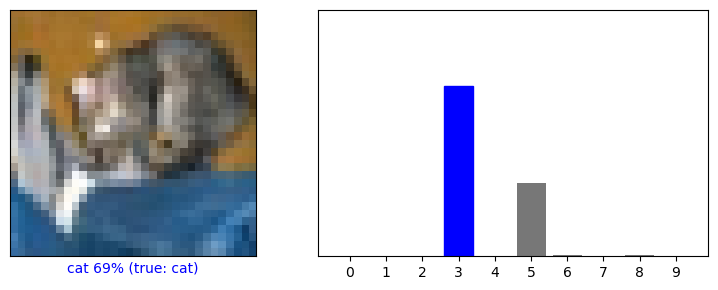

In [9]:

softmax = nn.Softmax(dim=1)
img, true_label = test_ds[0]
with torch.no_grad():
    probs = softmax(model(img.unsqueeze(0).to(device))).cpu().numpy()[0]
npimg = img.permute(1,2,0).numpy()
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.xticks([]); plt.yticks([]); plt.grid(False)
plt.imshow(npimg)
pred_label = int(np.argmax(probs))
plt.xlabel(f'{class_names[pred_label]} {100*np.max(probs):2.0f}% (true: {class_names[true_label]})',
           color=('blue' if pred_label == true_label else 'red'))
plt.subplot(1,2,2)
plt.grid(False); plt.xticks(range(10)); plt.yticks([])
bars = plt.bar(range(10), probs, color='#777777')
plt.ylim([0,1])
bars[pred_label].set_color('red')
bars[true_label].set_color('blue')
plt.tight_layout(); plt.show()


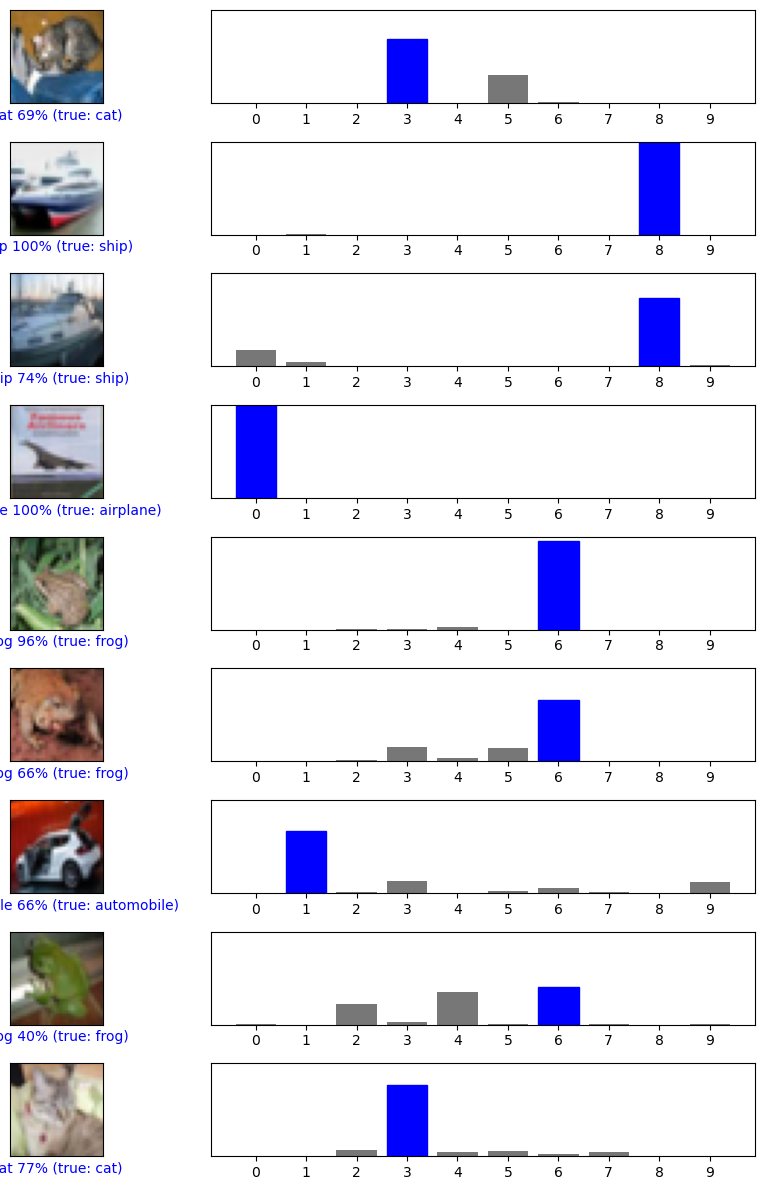

In [10]:

def plot_image(predictions_array, true_label, img):
    plt.grid(False); plt.xticks([]); plt.yticks([])
    predicted_label = int(np.argmax(predictions_array))
    color = 'blue' if predicted_label == true_label else 'red'
    plt.imshow(img)
    plt.xlabel(f'{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% (true: {class_names[true_label]})',
               color=color)

def plot_value_array(predictions_array, true_label):
    plt.grid(False); plt.xticks(range(10)); plt.yticks([])
    bars = plt.bar(range(10), predictions_array, color='#777777')
    plt.ylim([0,1])
    predicted_label = int(np.argmax(predictions_array))
    bars[predicted_label].set_color('red')
    bars[true_label].set_color('blue')

N = 9
imgs, labels = [], []
for i in range(N):
    im, lab = test_ds[i]
    imgs.append(im)
    labels.append(lab)
xb = torch.stack(imgs).to(device)
with torch.no_grad():
    probs_batch = softmax(model(xb)).cpu().numpy()
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,12))
for i in range(N):
    npimg = imgs[i].permute(1,2,0).numpy()
    plt.subplot(N, 2, 2*i+1)
    plot_image(probs_batch[i], labels[i], npimg)
    plt.subplot(N, 2, 2*i+2)
    plot_value_array(probs_batch[i], labels[i])
plt.tight_layout(); plt.show()
